<a href="https://colab.research.google.com/github/mayajdias/A03-knn/blob/main/aknn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Maya Dias

**Date:** 09/30/2026

In [ ]:
#Phase 1 Q1

1. Regression is for when the target is a number, like `baseline sales` or price, and classification is for when the target is a category, like vehicle `class` or survival. In kNN, regression averages the outcomes of the k nearest neighbors, while classification predicts the most common class among them.

2. A confusion table (matrix) counts predictions by actual class (rows) and predicted class (columns). The diagonal cells are the correct predictions and the off-diagonal cells are misclassifications. For a yes/no problem, the cells are true negative, false positive, false negative, and true positive. It helps because accuracy alone doesn't show which classes are getting misclassified. In the car example with k = 9, the matrix showed that the model never predicts "station wagon," because other classes are more common among the nearest neighbors.

3. SSE is the sum of squared errors. You take each residual (actual y minus predicted ŷ), square it, and add them all up over the validation observations. It tells us how big the model's prediction errors are overall, and lower validation SSE means smaller errors on that validation set. Squaring also means over- and underpredictions don't cancel each other out.

4. Overfitting is when the model fits noise in the training data instead of the real pattern. Very small k does this (like k = 2 in the slides), so predictions vary sharply. Underfitting is the opposite. The model is too simple to capture differences between observations, which happens with very large k (like k = 470), where predictions are nearly the same for every observation.

5. Generalization means predicting well on data that wasn't used to fit the model, and choosing k by training error alone can lead to overfitting. Training error would favor a small k that just follows the training data. So we fit models on the training set and compare each k on a separate validation set. In the slides, validation SSE was lowest at k = 13, while training SSE alone would have favored a smaller k. Then we keep a separate test set for the final evaluation, so the data used to choose k isn't also used to judge the final model. One caveat is that the estimate depends on how you split the data, so another split might give a different best k. (The slides call the set used to choose k the "validation set" and the final one the "test set," so I used those terms.)

6. The slides only partly cover this, so some of it is my own reasoning. From the slides, a class label is the most common class among the k neighbors, and a probability distribution is each class's proportion, which is its neighbor count divided by k. A class label is simple, gives one clear answer, and plugs straight into a confusion matrix and accuracy. The downside is that it hides how the vote went, since a 5-to-4 vote looks the same as a 9-to-0 vote. It can also ignore smaller classes entirely, like station wagons in the k = 9 example. Probabilities keep the whole picture of the neighbors' votes, so you can see how confident the model is and what the runner-up class is, though that part is my own reasoning and not from the slides. The slides don't list weaknesses for probabilities, but I'd guess they're harder to summarize with one number like accuracy, and with a small k the proportions are chunky because they can only be multiples of 1/k.

shape: (338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1

Mines of each type:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Feature summaries:
       voltage   height     soil
count  338.000  338.000  338.000
mean     0.431    0.509    0.504
std      0.196    0.306    0.344
min      0.198    0.000    0.000
25%      0.310    0.273    0.200
50%      0.360    0.545    0.600
75%      0.483    0.727    0.800
max      1.000    1.000    1.000


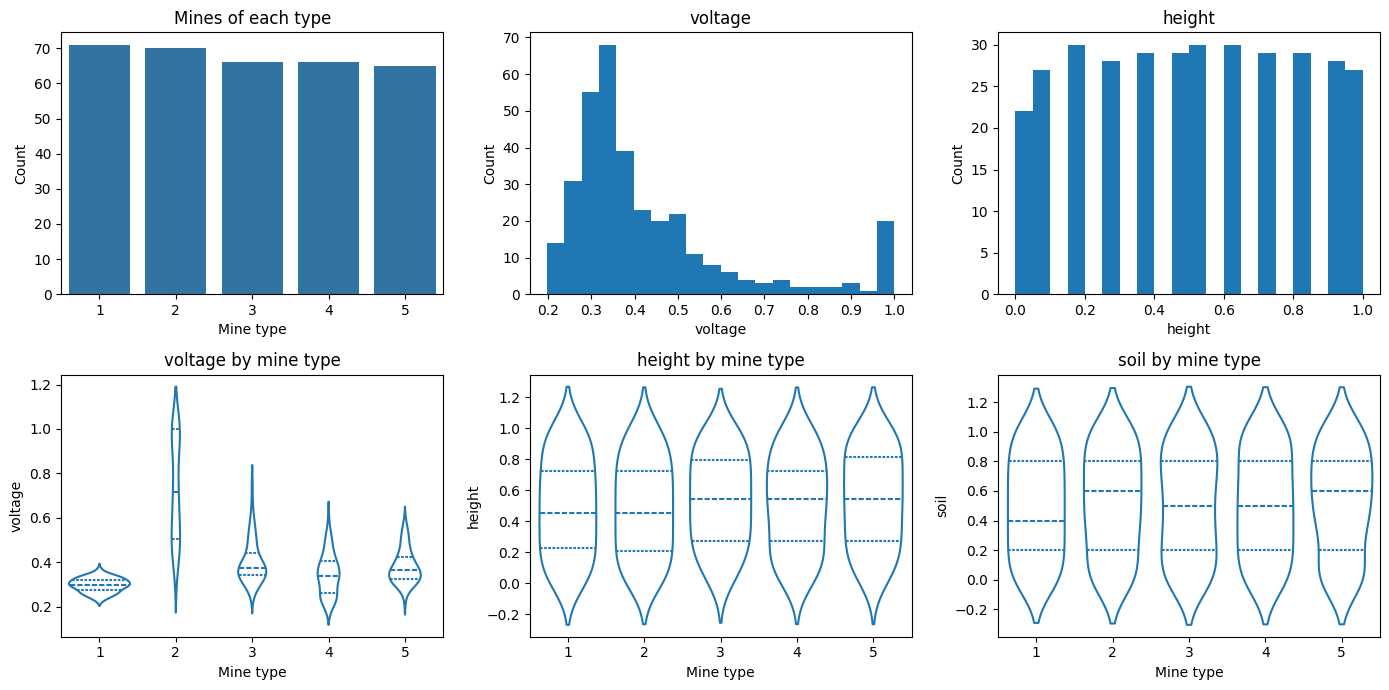


Mean and sd of each feature by mine type:
          voltage        height          soil       
             mean    std   mean    std   mean    std
mine_type                                           
1           0.296  0.032  0.496  0.316  0.493  0.341
2           0.721  0.222  0.487  0.311  0.509  0.345
3           0.402  0.098  0.528  0.296  0.497  0.351
4           0.345  0.093  0.507  0.306  0.503  0.348
5           0.380  0.076  0.530  0.306  0.517  0.346

train size: 169  test size: 169
           train  test
mine_type             
1             37    34
2             32    38
3             36    30
4             28    38
5             36    29

best k: 2  test accuracy: 0.45


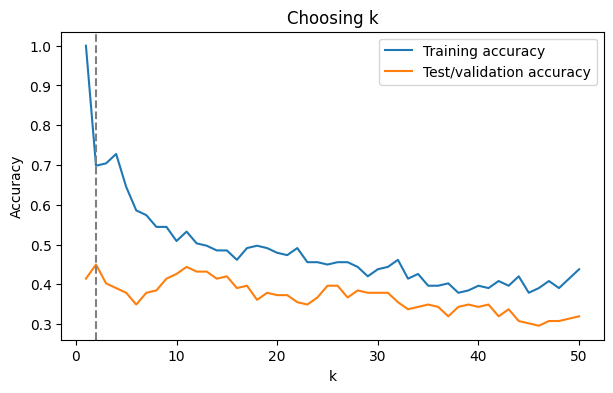


Confusion table (rows = actual, columns = predicted):
          pred 1  pred 2  pred 3  pred 4  pred 5
actual 1      21       1       6       4       2
actual 2       0      33       2       3       0
actual 3       5       5      10       6       4
actual 4      13       5      10       9       1
actual 5      10       1       8       7       3

Overall accuracy: 0.45

Per-class results:
           n_actual  n_predicted  recall  precision
mine_type                                          
1                34           49    0.62       0.43
2                38           45    0.87       0.73
3                30           36    0.33       0.28
4                38           29    0.24       0.31
5                29           10    0.10       0.30

Share of test mines where both neighbors agree: 0.379
Accuracy when they agree:    0.625
Accuracy when they disagree: 0.343


In [ ]:
# Phase 1 Q2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# 1. Load the data and do EDA
try:
    df = pd.read_csv("land_mines.csv")
except FileNotFoundError:
    from google.colab import files
    files.upload()
    df = pd.read_csv("land_mines.csv")

print("shape:", df.shape)
print(df.isna().sum())
print(df.head())

print("\nMines of each type:")
print(df["mine_type"].value_counts().sort_index())

print("\nFeature summaries:")
print(df[["voltage", "height", "soil"]].describe().round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
sns.countplot(data=df, x="mine_type", ax=axes[0, 0])
axes[0, 0].set(title="Mines of each type", xlabel="Mine type", ylabel="Count")
for ax, col in zip([axes[0, 1], axes[0, 2]], ["voltage", "height"]):
    df[col].hist(bins=20, grid=False, ax=ax)
    ax.set(title=col, xlabel=col, ylabel="Count")
for ax, col in zip(axes[1], ["voltage", "height", "soil"]):
    sns.violinplot(data=df, x="mine_type", y=col, inner="quart", fill=False, ax=ax)
    ax.set(title=f"{col} by mine type", xlabel="Mine type")
plt.tight_layout()
plt.show()

print("\nMean and sd of each feature by mine type:")
print(df.groupby("mine_type")[["voltage", "height", "soil"]].agg(["mean", "std"]).round(3))

# EDA takeaways: the classes are balanced (65 to 71 each). Only voltage changes much
# with mine type: type 2 is high, type 1 is low and tight, and types 3-5 overlap.
# height and soil look about the same for every type.

# 2. Split 50/50, then scale (fit the scaler on train only)
X_raw = df[["voltage", "height", "soil"]]
y = df["mine_type"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.50, random_state=65
)
print("\ntrain size:", len(X_train_raw), " test size:", len(X_test_raw))
print(pd.DataFrame({"train": y_train.value_counts().sort_index(),
                    "test": y_test.value_counts().sort_index()}))

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 3. Build the kNN classifier and choose k
ks = np.arange(1, 51)
train_acc, test_acc = [], []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    train_acc.append(np.mean(model.predict(X_train) == y_train))
    test_acc.append(np.mean(model.predict(X_test) == y_test))

k_star = int(ks[np.argmax(test_acc)])
print("\nbest k:", k_star, " test accuracy:", round(max(test_acc), 3))

plt.figure(figsize=(7, 4))
plt.plot(ks, train_acc, label="Training accuracy")
plt.plot(ks, test_acc, label="Test/validation accuracy")
plt.axvline(k_star, linestyle="--", color="gray")
plt.title("Choosing k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# I pick the k with the highest accuracy on the test set, since training error always
# favors tiny k (overfitting). That gives k = 2, but the curve is flat and noisy, so
# another split could give a different k.

# 4. Confusion table for the best model
best_model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_pred = best_model.predict(X_test)

labels = [1, 2, 3, 4, 5]
cm = pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=labels),
    index=[f"actual {c}" for c in labels],
    columns=[f"pred {c}" for c in labels],
)
print("\nConfusion table (rows = actual, columns = predicted):")
print(cm)
print("\nOverall accuracy:", round(np.mean(y_pred == y_test), 3))

# recall = correct / row total, precision = correct / column total
per_class = pd.DataFrame({
    "n_actual": cm.sum(axis=1).values,
    "n_predicted": cm.sum(axis=0).values,
    "recall": (np.diag(cm) / cm.sum(axis=1).values).round(2),
    "precision": (np.diag(cm) / cm.sum(axis=0).values).round(2),
}, index=labels)
per_class.index.name = "mine_type"
print("\nPer-class results:")
print(per_class)

# Accuracy is only about 45% (chance is about 20%). Type 2 is best (recall 0.87,
# precision 0.73). Type 1 catches most real ones (0.62) but only 43% of its predictions
# are right. Types 3, 4, and 5 are poor (recall 0.33, 0.24, 0.10).

# 5. Using the model in practice
proba = best_model.predict_proba(X_test)
unanimous = proba.max(axis=1) == 1.0

print("\nShare of test mines where both neighbors agree:", round(unanimous.mean(), 3))
print("Accuracy when they agree:   ", round(np.mean(y_pred[unanimous] == y_test.values[unanimous]), 3))
print("Accuracy when they disagree:", round(np.mean(y_pred[~unanimous] == y_test.values[~unanimous]), 3))

# Advice: a label like "type 1" isn't enough evidence on its own, since fewer than half
# of the mines called type 1 really are type 1. Use the model as a screening tool and
# confirm the type another way before acting. Look at the neighbor proportions too,
# because predictions where the neighbors agree are much more reliable. Trust "type 2"
# predictions more than 3, 4, or 5, and treat those as "unknown type". Decide which
# mistakes are most dangerous, and get better features, since height and soil barely help.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]